<a href="https://www.kaggle.com/code/hashemili/heart-disease-risk-prediction-ili?scriptVersionId=225705641" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

## Let's Get Started

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, recall_score, f1_score
from sklearn.metrics import classification_report

plt.style.use('fivethirtyeight')

import warnings
warnings.filterwarnings('ignore')

## Explore Data

In [2]:
df = pd.read_csv(r'/kaggle/input/heart-disease-risk-prediction-dataset/heart_disease_risk_dataset_earlymed.csv')

In [3]:
df.head()

,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,48.0,0.0
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,46.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,66.0,0.0
3,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,60.0,1.0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,69.0,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Chest_Pain           70000 non-null  float64
 1   Shortness_of_Breath  70000 non-null  float64
 2   Fatigue              70000 non-null  float64
 3   Palpitations         70000 non-null  float64
 4   Dizziness            70000 non-null  float64
 5   Swelling             70000 non-null  float64
 6   Pain_Arms_Jaw_Back   70000 non-null  float64
 7   Cold_Sweats_Nausea   70000 non-null  float64
 8   High_BP              70000 non-null  float64
 9   High_Cholesterol     70000 non-null  float64
 10  Diabetes             70000 non-null  float64
 11  Smoking              70000 non-null  float64
 12  Obesity              70000 non-null  float64
 13  Sedentary_Lifestyle  70000 non-null  float64
 14  Family_History       70000 non-null  float64
 15  Chronic_Stress       70000 non-null 

In [5]:
df = df.astype(int)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Chest_Pain           70000 non-null  int64
 1   Shortness_of_Breath  70000 non-null  int64
 2   Fatigue              70000 non-null  int64
 3   Palpitations         70000 non-null  int64
 4   Dizziness            70000 non-null  int64
 5   Swelling             70000 non-null  int64
 6   Pain_Arms_Jaw_Back   70000 non-null  int64
 7   Cold_Sweats_Nausea   70000 non-null  int64
 8   High_BP              70000 non-null  int64
 9   High_Cholesterol     70000 non-null  int64
 10  Diabetes             70000 non-null  int64
 11  Smoking              70000 non-null  int64
 12  Obesity              70000 non-null  int64
 13  Sedentary_Lifestyle  70000 non-null  int64
 14  Family_History       70000 non-null  int64
 15  Chronic_Stress       70000 non-null  int64
 16  Gender               7

In [7]:
df.describe()

,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,0.499229,0.500586,0.498571,0.498729,0.501414,0.498929,0.501500,0.502457,0.497429,0.499214,0.500643,0.502971,0.499157,0.503543,0.497629,0.499957,0.548929,54.461986,0.500000
std,0.500003,0.500003,0.500002,0.500002,0.500002,0.500002,0.500001,0.499998,0.499997,0.500003,0.500003,0.499995,0.500003,0.499991,0.499998,0.500004,0.497604,16.410794,0.500004
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45.000000,0.000000
50%,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,56.000000,0.500000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,67.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,84.000000,1.000000


**After examination, it was found that the data was clean and ready for analysis**

## Data Analysis

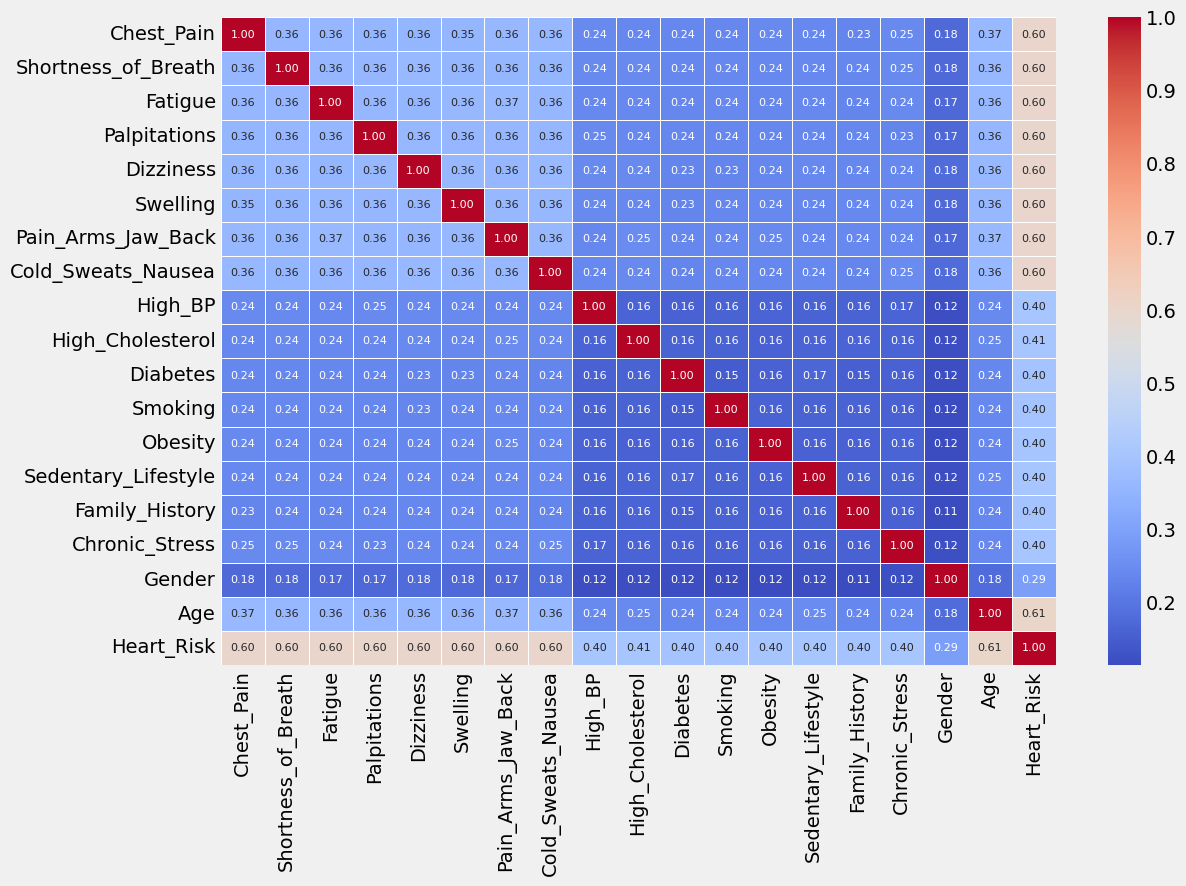

In [8]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', linewidths=0.6, cmap='coolwarm', annot_kws={"size": 8})
plt.show()

**It is clear that Gender has the least impact on Heart_Risk, so I want to run a data trail**

In [9]:
df = df.drop(columns=['Gender'])

## Create Our Models

In [10]:
x= df.drop('Heart_Risk', axis=1)
y= df['Heart_Risk']

In [11]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=.2)

In [12]:
model1= LogisticRegression()
model2= SVC()
model3= RandomForestClassifier()
model4= GradientBoostingClassifier(n_estimators=1000)

In [13]:
columns=['LogisticRegression','SVC','RandomForestClassifier','GradientBoostingClassifier']
result1=[]
result2=[]
result3=[]

LogisticRegression()
accuracy is : 0.9917142857142857 recall is : 0.9913854989231874 f1 is : 0.9916702570731006


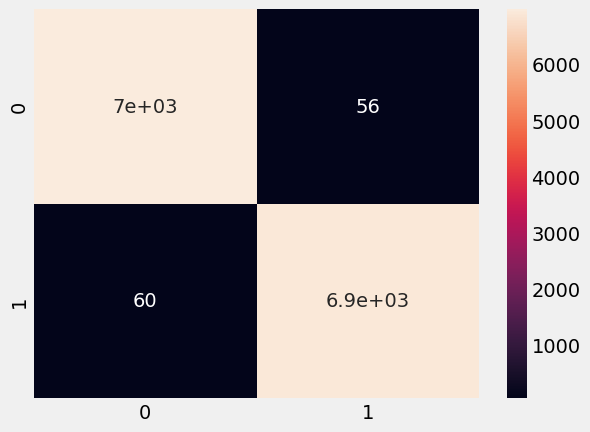

In [14]:
def cal(model):
    model.fit(x_train,y_train)
    pre=model.predict(x_test)
    accuracy=accuracy_score(pre,y_test)
    recall=recall_score(pre,y_test)
    f1=f1_score(pre,y_test)
    
    result1.append(accuracy)
    result2.append(recall)
    result3.append(f1)

    sns.heatmap(confusion_matrix(pre,y_test),annot=True)
    print(model)
    print('accuracy is :',accuracy,'recall is :',recall,'f1 is :',f1)
cal(model1)

SVC()
accuracy is : 0.9925714285714285 recall is : 0.9914003153217715 f1 is : 0.9925383842732101


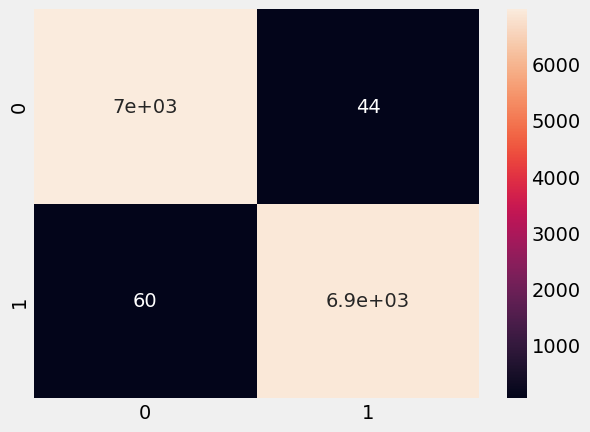

In [15]:
cal(model2)

RandomForestClassifier()
accuracy is : 0.9925 recall is : 0.9913990825688074 f1 is : 0.9924660974384731


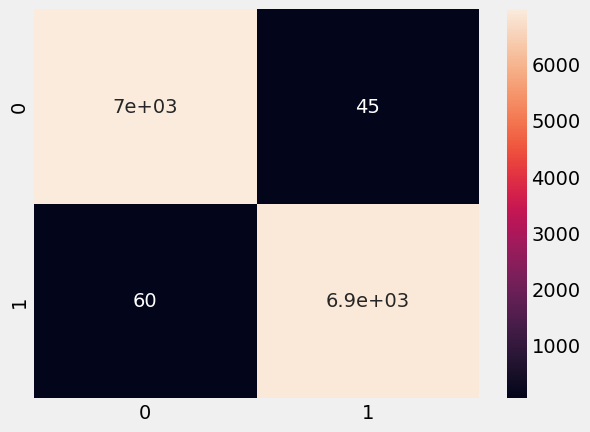

In [16]:
cal(model3)

GradientBoostingClassifier(n_estimators=1000)
accuracy is : 0.9934285714285714 recall is : 0.9925426645633156 f1 is : 0.9933974450983206


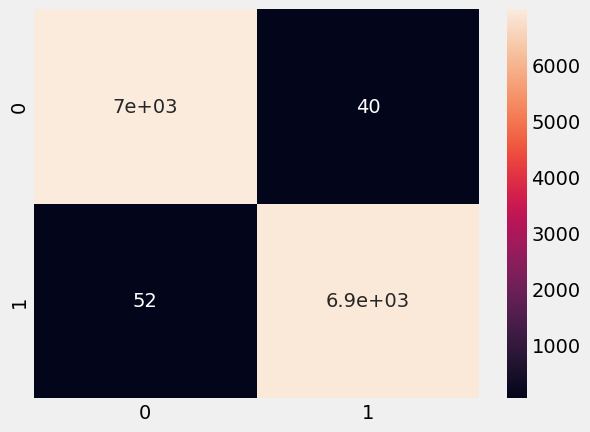

In [17]:
cal(model4)

In [18]:
result1

[0.9917142857142857, 0.9925714285714285, 0.9925, 0.9934285714285714]

In [19]:
result2

[0.9913854989231874,
 0.9914003153217715,
 0.9913990825688074,
 0.9925426645633156]

In [20]:
result3

[0.9916702570731006,
 0.9925383842732101,
 0.9924660974384731,
 0.9933974450983206]

In [21]:
print(len(columns)) 
print(len(result1)) 
print(len(result2)) 
print(len(result3))

4
4
4
4


In [22]:
min_length = min(len(columns), len(result1), len(result2), len(result3))

columns = columns[:min_length]
result1 = result1[:min_length]
result2 = result2[:min_length]
result3 = result3[:min_length]

In [23]:
FinalResult= pd.DataFrame({'Algorithm':columns,'Accuracies':result1,'Recall':result2,'FScore':result3})
FinalResult

,Algorithm,Accuracies,Recall,FScore
0,LogisticRegression,0.991714,0.991385,0.991670
1,SVC,0.992571,0.991400,0.992538
2,RandomForestClassifier,0.992500,0.991399,0.992466
3,GradientBoostingClassifier,0.993429,0.992543,0.993397


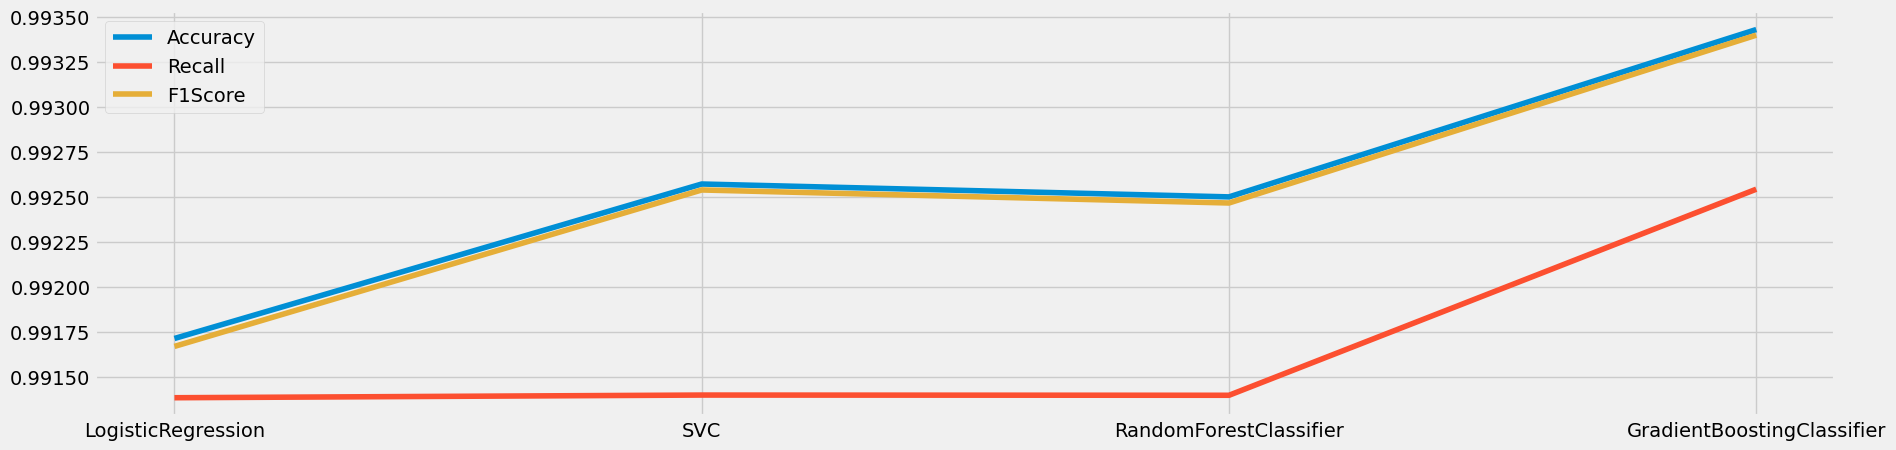

In [24]:
fig,ax=plt.subplots(figsize=(20,5))
plt.plot(FinalResult.Algorithm,result1,label='Accuracy')
plt.plot(FinalResult.Algorithm,result2,label='Recall')
plt.plot(FinalResult.Algorithm,result3,label='F1Score')
plt.legend()
plt.show()